# SNA Analysis: Instagram Social Network (2 Layer)

- `user_with_comment_in_post.csv` → edge table (commenter → post_owner)
- `user_comments_received.csv`    → in-degree proxy per post owner
- `post_comment_rank.csv`         → post-level comment rank
- `dataset_clean.csv`             → raw dataset untuk node attributes

---

## Edge Architecture

```
PRIMARY  →  comment-on-post
            commenter_username → post_owner_username
            weight = comment_count (0.4) + total_like (0.2) + total_interactions (0.4)

LAYER 2  →  mention

SKIP     →  co-keyword sebagai edge (terlalu noisy)
            → disimpan sebagai node attribute active_keywords
```

## Centrality yang dihitung

| Metric | Interpretasi Bisnis |
|---|---|
| **In-degree** | Berapa unique commenter datang ke akun ini → popularitas |
| **PageRank** | Engagement yang datang ke suatu node → directed graph  |
| **Betweenness** | Jembatan antar komunitas → paling valuable untuk brand outreach |
| **Out-degree** | Seberapa aktif akun ini komentar ke akun lain  → dipakai untuk: cari buzzer, hub detection (node yang menyebarkan interaksi), community engager (akun yang connect ke banyak orang) |
| **Authority (HITS)** | Hub (tinggi) → akun yang sering engage ke akun penting & authority (tinggi) → akun yang sering dikomentari / dimention oleh akun penting  |
| **Eigenvector** | Node dianggap penting kalau dia terhubung ke node penting lainnya “temenan sama orang terkenal bikin lu ikut penting” → undirected graph |

## Pipeline
1. Install & Import
2. Load Data & Validasi
3. Build Network Graph
4. Network Overview Statistics
5. Centrality Metrics Computation
6. Influencer Tier Ranking
7. Community Detection (Louvain)
8. White Space Analysis
9. Export untuk Backend API


---
## 0. Install & Import

In [45]:
# ── Install dependencies (jalankan sekali) ─────────────────────────────────
!pip install networkx python-louvain pyvis pandas numpy matplotlib seaborn scipy -q


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
from collections import Counter
from pyvis.network import Network
import community as community_louvain

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

print('✅ Libraries loaded')

✅ Libraries loaded


---
## 1. Load Data & Validasi

#### a. Fix URL corrupt

In [47]:
df_raw = pd.read_csv('../data/processed/dataset_final_clean_revised.csv', low_memory=False)

# Fix URL corrupt
df_raw.loc[2001, 'url'] = 'https://www.instagram.com/p/DXRxd6kGSuV/'

# Verifikasi
print(df_raw.loc[2001, ['username', 'url']])

# Simpan kembali
df_raw.to_csv('../data/processed/dataset_final_clean_revised.csv', index=False)
print("Dataset disimpan.")

username                                       350id
url         https://www.instagram.com/p/DXRxd6kGSuV/
Name: 2001, dtype: object
Dataset disimpan.


#### b. Extract mention from content (karena kolom mention di dataset clean masih ada yang belum ke-extract), including filter email domain

In [48]:
import re
import pandas as pd

df_raw = pd.read_csv('../data/processed/dataset_final_clean_revised.csv', low_memory=False)

# ── Config ──────────────────────────────────────────────────────────────────
MENTION_PATTERN = re.compile(r"(?<![A-Za-z0-9_.])@([A-Za-z0-9_.]+)")
HASHTAG_PATTERN = re.compile(r"#([A-Za-z0-9_]+)")

EMAIL_DOMAINS = (".com", ".net", ".org", ".ac", ".edu")

# ── Extract functions ────────────────────────────────────────────────────────
def extract_mentions(text):
    if pd.isna(text):
        return []
    mentions = MENTION_PATTERN.findall(str(text))
    cleaned = []
    for m in mentions:
        m_lower = m.lower()
        if any(domain in m_lower for domain in EMAIL_DOMAINS):
            continue
        cleaned.append(m_lower)
    return list(sorted(set(cleaned)))

def extract_hashtags(text):
    if pd.isna(text):
        return []
    hashtags = HASHTAG_PATTERN.findall(str(text))
    return list(sorted(set(h.lower() for h in hashtags)))

# ── Apply ────────────────────────────────────────────────────────────────────
df = df_raw.copy()  # kerja di copy, raw tetap aman
df['username_lower'] = df['username'].str.lower().str.strip()
df['mentions']       = df['content'].apply(extract_mentions)
df['hashtags']       = df['content'].apply(extract_hashtags)
df['n_mentions']     = df['mentions'].apply(len)
df['n_hashtags']     = df['hashtags'].apply(len)

print(f"Total mentions found : {df['n_mentions'].sum()}")
print(f"Total hashtags found : {df['n_hashtags'].sum()}")
print(f"Rows with mentions   : {(df['n_mentions'] > 0).sum()}")
print(f"Rows with hashtags   : {(df['n_hashtags'] > 0).sum()}")

Total mentions found : 136
Total hashtags found : 8591
Rows with mentions   : 90
Rows with hashtags   : 1278


---
## 2. Build Edge List

### a. Mention-based

#### - Cek self-loop rows + delete

In [49]:
# ── Explode & cek self-loop ──────────────────────────────────────────────────
df_mention = df[df['n_mentions'] > 0][['username_lower', 'mentions', 'url']].copy()

df_exploded_raw = (
    df_mention
    .explode('mentions')
    .rename(columns={'username_lower': 'source', 'mentions': 'target'})
)

df_exploded_raw = df_exploded_raw[
    df_exploded_raw['target'].notna() &
    (df_exploded_raw['target'].astype(str).str.strip() != '')
]

# Cek self-loop
self_loop = df_exploded_raw[df_exploded_raw['source'] == df_exploded_raw['target']]
print(f"Self-loop rows   : {len(self_loop)}")
print(self_loop[['source', 'target']].to_string())

# Filter self-loop
edges_clean = df_exploded_raw[df_exploded_raw['source'] != df_exploded_raw['target']].copy()

# Dedup: source + target + url sama → hapus
before = len(edges_clean)
edges_clean = edges_clean.drop_duplicates(subset=['source', 'target', 'url']).copy()
after = len(edges_clean)

print(f"\nRaw edge rows            : {len(df_exploded_raw)}")
print(f"Setelah filter self-loop : {before}")
print(f"Setelah dedup            : {after}")
print(f"Dihapus (dedup)          : {before - after}")

# Cek madiuntoday
print("\nCek madiuntoday:")
print(df_exploded_raw[df_exploded_raw['target'].str.contains('madiuntoday', na=False)])

Self-loop rows   : 26
                  source              target
19          mancingsaham        mancingsaham
29      bloombergtechnoz    bloombergtechnoz
44           milenianews         milenianews
65      bloombergtechnoz    bloombergtechnoz
68         infoterkinimu       infoterkinimu
235              asep19_             asep19_
394            kompascom           kompascom
446          officialicm         officialicm
554      alingenglish.id     alingenglish.id
604            dumpjarea           dumpjarea
674      heraldsulselbar     heraldsulselbar
809            aktualcom           aktualcom
972         waspadadotid        waspadadotid
1142    bloombergtechnoz    bloombergtechnoz
1541         likecirebon         likecirebon
1615          periklindo          periklindo
1696  sankelux_sankeindo  sankelux_sankeindo
1698           beldocuan           beldocuan
1711        cekberitanya        cekberitanya
1727       tumbuhkaya.id       tumbuhkaya.id
1744     reformsyndicate     refo

#### - Make sure username yang berakhiran domain tetap ke-extract

In [50]:
import pandas as pd

EMAIL_DOMAINS = [".com", ".co", ".id", ".net", ".org", ".ac", ".edu"]

# ── Cek username di dataset ──────────────────────────────────────────────────
all_usernames = df['username_lower'].dropna().unique()

print("=== Username yang berakhiran domain ===\n")
for domain in EMAIL_DOMAINS:
    matches = [u for u in all_usernames if u.endswith(domain)]
    print(f"  {domain:6s} → {len(matches)} akun : {matches}")

# ── Cek mentioned username (target dari df_exploded_raw) ─────────────────────
print("\n=== Mentioned username yang berakhiran domain ===\n")
all_targets = df_exploded_raw['target'].dropna().str.lower().str.strip().unique()

for domain in EMAIL_DOMAINS:
    matches = [u for u in all_targets if u.endswith(domain)]
    print(f"  {domain:6s} → {len(matches)} akun : {matches}")

=== Username yang berakhiran domain ===

  .com   → 0 akun : []
  .co    → 3 akun : ['tripol.co', 'feedcollective.co', 'poppublic.co']
  .id    → 46 akun : ['publikfun.id', 'beritaa1.id', 'vivanusantara.id', 'yuripedia.id', 'yudhstira.id', 'detiktimes.id', 'kabartimur.id', 'policenews.id', 'sumbartalk.id', 'madiuntoday.id', 'macanasia.id', 'genvoice.id', 'dheni.id', 'funderstand.id', 'cryfex.id', 'investortrust.id', 'alingenglish.id', 'danviro.id', 'komparasinews.id', 'exporthub.id', 'carbonaccounting.id', 'trashranger.id', 'laporan8.id', 'capitalinsight.id', 'posnews.co.id', 'rimbasatwa.id', 'sultanarab.id', 'linkkerja.id', 'vritimes.id', 'indovibing.id', 'partainasi.id', 'floresthink.id', 'iesr.id', 'anna_lim888.id', 'stonks.id', 'birukarbon.id', 'scvnews.id', 'tumbuhkaya.id', 'naturevolution.id', 'solarhub.id', 'eksposur.id', 'ahliana.co.id', 'perplatsi.id', 'peluangnews.id', 'lab45.id', 'birustock.id']
  .net   → 0 akun : []
  .org   → 0 akun : []
  .ac    → 0 akun : []
  .edu   → 

#### - Cek & delete duplikasi

In [51]:
# Convert mentions list -> string untuk keperluan cek duplikat
df['mentions_str'] = df['mentions'].apply(lambda x: str(sorted(x)) if isinstance(x, list) else str(x))

df_has_mention = df[df['n_mentions'] > 0].copy()
dup_mask = df_has_mention.duplicated(subset=['username', 'mentions_str'], keep=False)
df_dups = df_has_mention[dup_mask].sort_values(['username', 'mentions_str'])

print(f"Total baris duplikat : {len(df_dups)}")
print(f"Unique pasangan      : {df_dups.groupby(['username', 'mentions_str']).ngroups}")
print()

for (uname, mention_str), grp in df_dups.groupby(['username', 'mentions_str']):
    print(f"{'='*60}")
    print(f"username : {uname}")
    print(f"mentions : {mention_str}")
    print(f"Jumlah duplikat : {len(grp)} baris (index: {grp.index.tolist()})")
    print()

    same_cols, diff_cols = [], []
    for col in grp.columns:
        try:
            n_unique = grp[col].astype(str).nunique()
        except Exception:
            n_unique = 2
        (same_cols if n_unique == 1 else diff_cols).append(col)

    print(f"✅ Kolom SAMA ({len(same_cols)}) : {same_cols}")
    print(f"❌ Kolom BEDA ({len(diff_cols)}) : {diff_cols}")

    if diff_cols:
        print("\nDetail kolom yang beda:")
        safe_diff = [c for c in diff_cols if grp[c].apply(lambda x: not isinstance(x, list)).all()]
        if safe_diff:
            print(grp[safe_diff].to_string())
    print()

Total baris duplikat : 10
Unique pasangan      : 4

username : 350id
mentions : ['bahlillahadalia', 'prabowo']
Jumlah duplikat : 2 baris (index: [433, 434])

✅ Kolom SAMA (21) : ['date', 'url', 'content', 'username', 'total_like', 'total_interaction', 'content_processed', 'sentiment_label', 'sentiment_score', 'post_id', 'comment_id', 'is_comment', 'year_month', 'day_of_week', 'hour', 'mentions', 'hashtags', 'n_mentions', 'n_hashtags', 'username_lower', 'mentions_str']
❌ Kolom BEDA (1) : ['keyword']

Detail kolom yang beda:
          keyword
433    SubsidiBBM
434  KrisisEnergi

username : bloombergtechnoz
mentions : ['bloombergtechnoz']
Jumlah duplikat : 3 baris (index: [29, 65, 1142])

✅ Kolom SAMA (10) : ['keyword', 'username', 'total_interaction', 'sentiment_label', 'comment_id', 'is_comment', 'mentions', 'n_mentions', 'username_lower', 'mentions_str']
❌ Kolom BEDA (12) : ['date', 'url', 'content', 'total_like', 'content_processed', 'sentiment_score', 'post_id', 'year_month', 'day_of

In [52]:
# Cek duplikat di edges_clean setelah dedup
dup_mask = edges_clean.duplicated(subset=['source', 'target'], keep=False)
df_dups = edges_clean[dup_mask].sort_values(['source', 'target'])

print(f"Total baris duplikat : {len(df_dups)}")
print(f"Unique pasangan      : {df_dups.groupby(['source', 'target']).ngroups}")
print()

for (src, tgt), grp in df_dups.groupby(['source', 'target']):
    print(f"{'='*60}")
    print(f"source  : {src}")
    print(f"target  : {tgt}")
    print(f"Jumlah  : {len(grp)} baris (index: {grp.index.tolist()})")
    print(grp[['source', 'target', 'url']].to_string())
    print()

Total baris duplikat : 10
Unique pasangan      : 5

source  : 350id
target  : bahlillahadalia
Jumlah  : 2 baris (index: [433, 2001])
     source           target                                       url
433   350id  bahlillahadalia  https://www.instagram.com/p/DWtrBHeGd5H/
2001  350id  bahlillahadalia  https://www.instagram.com/p/DXRxd6kGSuV/

source  : 350id
target  : prabowo
Jumlah  : 2 baris (index: [433, 2001])
     source   target                                       url
433   350id  prabowo  https://www.instagram.com/p/DWtrBHeGd5H/
2001  350id  prabowo  https://www.instagram.com/p/DXRxd6kGSuV/

source  : ditlitka.ppidunia
target  : arroyyanmas
Jumlah  : 2 baris (index: [1928, 2077])
                 source       target                                       url
1928  ditlitka.ppidunia  arroyyanmas  https://www.instagram.com/p/DXPmn0VDRh4/
2077  ditlitka.ppidunia  arroyyanmas  https://www.instagram.com/p/DXUySeQDvDS/

source  : ditlitka.ppidunia
target  : pembuat_jejak25
Jumlah  

In [53]:
# Hapus semua baris dengan source=ditlitka.ppidunia dan target=ppidunia (karena itu cuma collab aja)
edges_clean = edges_clean[~(
    (edges_clean['source'] == 'ditlitka.ppidunia') & 
    (edges_clean['target'] == 'ppidunia')
)].copy()

print(f"Sisa edges : {len(edges_clean)}")

Sisa edges : 106


In [54]:
corrupt_mask = edges_clean['url'].str.contains(r'[A-Za-z]:\\', na=False)
print(f"URL corrupt : {corrupt_mask.sum()} baris")

URL corrupt : 0 baris


In [55]:
print(df[['username', 'is_comment', 'post_id', 'total_like', 'total_interaction']].head(10))
print(df['is_comment'].value_counts())

              username  is_comment      post_id  total_like  total_interaction
0       timesindonesia       False  DTNdnzsiLZr           9                  0
1          satriamedia        True  DTNdnzsiLZr           0                  0
2            sindonews       False  DTUONtoiBGP         137                  0
3   kurnianto_susetiyo        True  DTUONtoiBGP           0                  0
4             law_roes        True  DTUONtoiBGP           0                  0
5             itongeka        True  DTUONtoiBGP           3                  3
6             brohar85        True  DTUONtoiBGP           0                  0
7              bem_su1        True  DTUONtoiBGP           3                  2
8           swarnorudi        True  DTUONtoiBGP           0                  0
9  wildang_abu_fadhlan        True  DTUONtoiBGP           3                  0
is_comment
False    1346
True      869
Name: count, dtype: int64


### b. Comment-based

In [56]:
# ── Comment-based edges ──────────────────────────────────────────────────────

# Pisah post dan komentar
df_posts    = df[df['is_comment'] == False][['username', 'post_id']].rename(columns={'username': 'target'})
df_comments = df[df['is_comment'] == True][['username', 'post_id', 'total_like', 'total_interaction']]

# Join commenter ke pemilik post via post_id
df_comment_edges = df_comments.merge(df_posts, on='post_id', how='inner')
df_comment_edges = df_comment_edges.rename(columns={'username': 'source'})

# Hapus self-loop
df_comment_edges = df_comment_edges[df_comment_edges['source'] != df_comment_edges['target']].copy()

# Agregasi per pasangan source-target
comment_edges = (
    df_comment_edges
    .groupby(['source', 'target'])
    .agg(
        total_comments    = ('post_id', 'count'),
        total_like        = ('total_like', 'sum'),
        total_interaction = ('total_interaction', 'sum')
    )
    .reset_index()
)

# Hitung weight
comment_edges['weight'] = comment_edges['total_comments'] + comment_edges['total_like'] + comment_edges['total_interaction']

print(f"Total comment-based edges : {len(comment_edges)}")
print(comment_edges.sort_values('weight', ascending=False).head(10).to_string())

Total comment-based edges : 823
                 source            target  total_comments  total_like  total_interaction  weight
641          ronnypunya       bitorexpost               1        1982                131    2114
206          delfistjun      warta.dotcom               1        1413                 26    1440
155            bi_lang_       bitorexpost               1        1009                 95    1105
618           ricky6510  koranbaliexpress               1         505                 84     590
329           hars_1928      warta.dotcom               1         559                 13     573
401  kata2_tak_tertulis       bitorexpost               1         353                 17     371
680          setiabuddi      banten.feeds               1         345                 11     357
544         om_sullllll  koranbaliexpress               1         344                 11     356
821           zildran27  koranbaliexpress               1         341                  3     34

In [57]:
result = comment_edges[comment_edges['target'] == 'bitorexpost']
print(f"Total username yang comment ke bitorexpost : {len(result)}")

Total username yang comment ke bitorexpost : 38


In [58]:
result = comment_edges[comment_edges['target'] == 'moltensalt.insight']
print(f"Total username yang comment ke moltensalt.insight : {len(result)}")

Total username yang comment ke moltensalt.insight : 18


In [59]:
summary = (
    comment_edges
    .groupby('target')
    .agg(
        total_unique_commenters = ('source', 'count'),
        total_comments_received = ('total_comments', 'sum')
    )
    .reset_index()
    .sort_values('total_comments_received', ascending=False)
)

print(summary.to_string())

                      target  total_unique_commenters  total_comments_received
100                sindonews                       78                       79
72        moltensalt.insight                       18                       42
80                otoproject                       38                       39
15               bitorexpost                       38                       38
69                   metrotv                       30                       30
66               luarbioskop                       29                       29
62          koranbaliexpress                       24                       26
20         cerah_indonesiaku                       10                       21
61                 kompascom                       20                       20
47           investordailyid                       19                       20
105        sukabumiupdatecom                       19                       19
32         feedcollective.co                       1

---
## 3. Build Graph

### a. Edge weight

#### - Comment + mention graph

### B. Graph: comment, mention, combined

In [60]:
import networkx as nx
import pandas as pd
import numpy as np

# 1. Aggregate edges: count the edge weight
def aggregate_edges(df_edges, source_col, target_col, int_col, like_col, weighted=True):
    if weighted:
        agg = (
            df_edges
            .groupby([source_col, target_col])
            .agg(
                edge_count        = (source_col, 'count'),
                total_like        = (like_col, 'sum'),
                total_interaction = (int_col, 'sum')
            )
            .reset_index()
        )
        agg['count_norm'] = agg['edge_count'] / agg['edge_count'].max() if agg['edge_count'].max() > 0 else 0
        agg['like_norm']  = agg['total_like']  / agg['total_like'].max()  if agg['total_like'].max()  > 0 else 0
        agg['int_norm']   = agg['total_interaction'] / agg['total_interaction'].max() if agg['total_interaction'].max() > 0 else 0

        agg['edge_weight'] = (
            agg['count_norm'] * 0.4
            + agg['like_norm']  * 0.2
            + agg['int_norm']   * 0.4
        )
    else:
        agg = (
            df_edges
            .groupby([source_col, target_col])
            .agg(edge_count = (source_col, 'count'))
            .reset_index()
        )
        # Normalize: edge_count / total semua mention di network
        total_mentions = agg['edge_count'].sum()
        agg['edge_weight'] = agg['edge_count'] / total_mentions if total_mentions > 0 else 0.0

    return agg


# 2. Build graphs: comment, mention, and combined
def build_graphs(df, edges_clean):
    uname_c = 'username'
    int_c   = 'total_interaction'
    like_c  = 'total_like'

    # Step 1: siapkan df_comment_edges
    df_posts    = df[df['is_comment'] == False][['username', 'post_id']].rename(columns={'username': 'target_username'})
    df_comments = df[df['is_comment'] == True][['username', 'post_id', 'total_like', 'total_interaction']]

    df_comment_edges = df_comments.merge(df_posts, on='post_id', how='inner')
    df_comment_edges = df_comment_edges[df_comment_edges['username'] != df_comment_edges['target_username']].copy()

    # Step 2: mention graph
    df_edges = edges_clean.rename(columns={'source': 'username', 'target': 'mentioned_username'})

    agg_mention = aggregate_edges(df_edges, 'username', 'mentioned_username', int_c, like_c, weighted=False)

    G_mention = nx.DiGraph()
    for _, row in agg_mention.iterrows():
        G_mention.add_edge(row['username'], row['mentioned_username'], weight=row['edge_weight'])

    # Step 3: comment graph
    agg_comment = aggregate_edges(df_comment_edges, uname_c, 'target_username', int_c, like_c, weighted=True)

    G_comment = nx.DiGraph()
    for _, row in agg_comment.iterrows():
        G_comment.add_edge(row[uname_c], row['target_username'], weight=row['edge_weight'])

    # Step 4: combined graph — tag has_comment dan has_mention per edge
    G_combined = nx.DiGraph()

    for u, v, d in G_comment.edges(data=True):
        G_combined.add_edge(u, v, **d, has_comment=True, has_mention=False)

    for u, v, d in G_mention.edges(data=True):
        if G_combined.has_edge(u, v):
            G_combined[u][v]['weight']     += d.get('weight', 1)
            G_combined[u][v]['has_mention'] = True
        else:
            G_combined.add_edge(u, v, **d, has_comment=False, has_mention=True)

    return {'comment': G_comment, 'mention': G_mention, 'combined': G_combined}


# 3. Compute Centrality
def compute_centrality(G, use_weighted_degree=False):
    nodes = list(G.nodes())

    if use_weighted_degree:
        in_deg_raw = dict(G.in_degree(weight='weight'))
        total = sum(in_deg_raw.values())
        in_degree = {n: v / total if total > 0 else 0 for n, v in in_deg_raw.items()}
    else:
        in_degree = nx.in_degree_centrality(G)

    pagerank    = nx.pagerank(G, alpha=0.85, weight='weight')
    betweenness = nx.betweenness_centrality(G, normalized=True, weight='weight')

    df_centrality = pd.DataFrame({
        'node'        : nodes,
        'in_degree'   : [in_degree.get(n, 0) for n in nodes],
        'pagerank'    : [pagerank.get(n, 0) for n in nodes],
        'betweenness' : [betweenness.get(n, 0) for n in nodes]
    }).sort_values('pagerank', ascending=False).reset_index(drop=True)

    return df_centrality


# 4. Run
graphs = build_graphs(df, edges_clean)

df_centrality_comment  = compute_centrality(graphs['comment'],  use_weighted_degree=False)
df_centrality_mention  = compute_centrality(graphs['mention'],  use_weighted_degree=True)
df_centrality_combined = compute_centrality(graphs['combined'], use_weighted_degree=False)

# Summary
for name, G in graphs.items():
    print(f"Graph {name:10s} → Nodes: {G.number_of_nodes():4d}, Edges: {G.number_of_edges():4d}")

print("\nTop 10 Comment Centrality:")
print(df_centrality_comment.head(10).to_string())

print("\nTop 10 Mention Centrality:")
print(df_centrality_mention.head(10).to_string())

print("\nTop 10 Combined Centrality:")
print(df_centrality_combined.head(10).to_string())

Graph comment    → Nodes:  931, Edges:  823
Graph mention    → Nodes:  139, Edges:  102
Graph combined   → Nodes: 1024, Edges:  921

Top 10 Comment Centrality:
                 node  in_degree  pagerank  betweenness
0           sindonews   0.083871  0.040832          0.0
1         bitorexpost   0.040860  0.020593          0.0
2          otoproject   0.040860  0.020109          0.0
3             metrotv   0.032258  0.016388          0.0
4         luarbioskop   0.031183  0.015862          0.0
5    koranbaliexpress   0.025806  0.013234          0.0
6           kompascom   0.021505  0.011131          0.0
7   sukabumiupdatecom   0.020430  0.010606          0.0
8     investordailyid   0.020430  0.010090          0.0
9  moltensalt.insight   0.019355  0.010080          0.0

Top 10 Mention Centrality:
              node  in_degree  pagerank  betweenness
0  riyan.nurrahman   0.056604  0.027883          0.0
1          prabowo   0.075472  0.023745          0.0
2    yuliawati.792   0.018868  0.0143

In [61]:
from scipy import stats

# ── Compute Centrality (upgraded) ───────────────────────────────────────────
def compute_centrality(G, use_weighted_degree=False):
    print('⏳  Computing centrality metrics...')

    # Degree metrics
    if use_weighted_degree:
        in_deg  = dict(G.in_degree(weight='weight'))
        out_deg = dict(G.out_degree(weight='weight'))
    else:
        in_deg  = nx.in_degree_centrality(G)
        out_deg = nx.out_degree_centrality(G)

    # Other centrality
    pr  = nx.pagerank(G, alpha=0.85, weight='weight')
    btw = nx.betweenness_centrality(G, normalized=True, weight='weight')

    # Build dataframe
    nodes = list(G.nodes())
    df_c  = pd.DataFrame({
        'username'   : nodes,
        'in_degree'  : [in_deg.get(n, 0)  for n in nodes],
        'out_degree' : [out_deg.get(n, 0) for n in nodes],
        'pagerank'   : [pr.get(n, 0)      for n in nodes],
        'betweenness': [btw.get(n, 0)     for n in nodes],
    })

    df_c['total_degree'] = df_c['in_degree'] + df_c['out_degree']

    # Z-score + percentile
    metric_cols = ['in_degree', 'out_degree', 'total_degree', 'pagerank', 'betweenness']
    for c in metric_cols:
        vals = df_c[c].fillna(0)
        df_c[f'{c}_zscore'] = 0.0 if vals.std() == 0 else stats.zscore(vals)
        df_c[f'{c}_pct']    = vals.rank(pct=True) * 100

    df_c = df_c.sort_values('pagerank', ascending=False).reset_index(drop=True)
    print('✅  Done.')
    return df_c


# ── Run ──────────────────────────────────────────────────────────────────────
df_centrality_comment  = compute_centrality(graphs['comment'],  use_weighted_degree=False)
df_centrality_mention  = compute_centrality(graphs['mention'],  use_weighted_degree=True)
df_centrality_combined = compute_centrality(graphs['combined'], use_weighted_degree=False)

# Primary graph
df_centrality = df_centrality_combined
df_centrality[['username', 'in_degree', 'out_degree', 'total_degree', 'pagerank', 'betweenness']].head(40)

⏳  Computing centrality metrics...
✅  Done.
⏳  Computing centrality metrics...
✅  Done.
⏳  Computing centrality metrics...
✅  Done.


,username,in_degree,out_degree,total_degree,pagerank,betweenness
0,sindonews,0.076246,0.000000,0.076246,0.037747,0.000000
1,bitorexpost,0.037146,0.000000,0.037146,0.018996,0.000000
2,otoproject,0.037146,0.000000,0.037146,0.018589,0.000000
3,metrotv,0.030303,0.000000,0.030303,0.015636,0.000000
4,luarbioskop,0.028348,0.000000,0.028348,0.014531,0.000000
5,koranbaliexpress,0.023460,0.000000,0.023460,0.012235,0.000000
6,kompascom,0.020528,0.000000,0.020528,0.010777,0.000000
7,sukabumiupdatecom,0.018573,0.000000,0.018573,0.009805,0.000000
8,investordailyid,0.018573,0.000000,0.018573,0.009328,0.000000
9,moltensalt.insight,0.017595,0.000000,0.017595,0.009319,0.000000


In [62]:
user = 'genergibersih'

for name, df_c in [('comment',  df_centrality_comment),
                   ('mention',  df_centrality_mention),
                   ('combined', df_centrality_combined)]:
    row = df_c[df_c['username'] == user]
    if not row.empty:
        print(f"{name:10s} → betweenness: {row['betweenness'].values[0]:.8f} | pagerank: {row['pagerank'].values[0]:.8f}")

comment    → betweenness: 0.00000000 | pagerank: 0.00587456
mention    → betweenness: 0.00000000 | pagerank: 0.00531051
combined   → betweenness: 0.00001243 | pagerank: 0.00515551


In [63]:
for name, df_c in [('comment',  df_centrality_comment),
                   ('mention',  df_centrality_mention),
                   ('combined', df_centrality_combined)]:
    print(f"\n{'='*50}")
    print(f"Top 10 Betweenness — {name.upper()} graph")
    print(f"{'='*50}")
    print(df_c[['username', 'betweenness']].nlargest(10, 'betweenness').to_string(index=False))


Top 10 Betweenness — COMMENT graph
          username  betweenness
         sindonews          0.0
       bitorexpost          0.0
        otoproject          0.0
           metrotv          0.0
       luarbioskop          0.0
  koranbaliexpress          0.0
         kompascom          0.0
 sukabumiupdatecom          0.0
   investordailyid          0.0
moltensalt.insight          0.0

Top 10 Betweenness — MENTION graph
       username  betweenness
riyan.nurrahman          0.0
        prabowo          0.0
  yuliawati.792          0.0
  alif.m.ismail          0.0
      kompascom          0.0
bahlillahadalia          0.0
      pertamina          0.0
         dpr_ri          0.0
    aktualforum          0.0
     jusufkalla          0.0

Top 10 Betweenness — COMBINED graph
         username  betweenness
    genergibersih 1.243417e-05
       lifeatgenb 3.825899e-06
    katadatagreen 9.564747e-07
joeliardisunendar 9.564747e-07
      giz_idasean 9.564747e-07
        sindonews 0.000000e+00
   


──────────────────────────────────────────────────────────
💡  CENTRALITY INSIGHTS
──────────────────────────────────────────────────────────
🏆  Most Influential (PageRank)   : ['sindonews', 'bitorexpost', 'otoproject']
🚀  Most Active (Out-Degree)      : ['merchandise_original_persib', 'aulia.rahmawati84', 'ratna_aden']
🔗  Most Connected (Total Degree) : ['sindonews', 'bitorexpost', 'otoproject']
🌉  Most Bridging (Betweenness)   : ['genergibersih', 'lifeatgenb', 'katadatagreen']

📊  Centrality Correlation Matrix:


,in_degree,out_degree,pagerank,betweenness
in_degree,1.000,-0.286,0.997,0.075
out_degree,-0.286,1.000,-0.268,0.053
pagerank,0.997,-0.268,1.000,0.073
betweenness,0.075,0.053,0.073,1.000


──────────────────────────────────────────────────────────


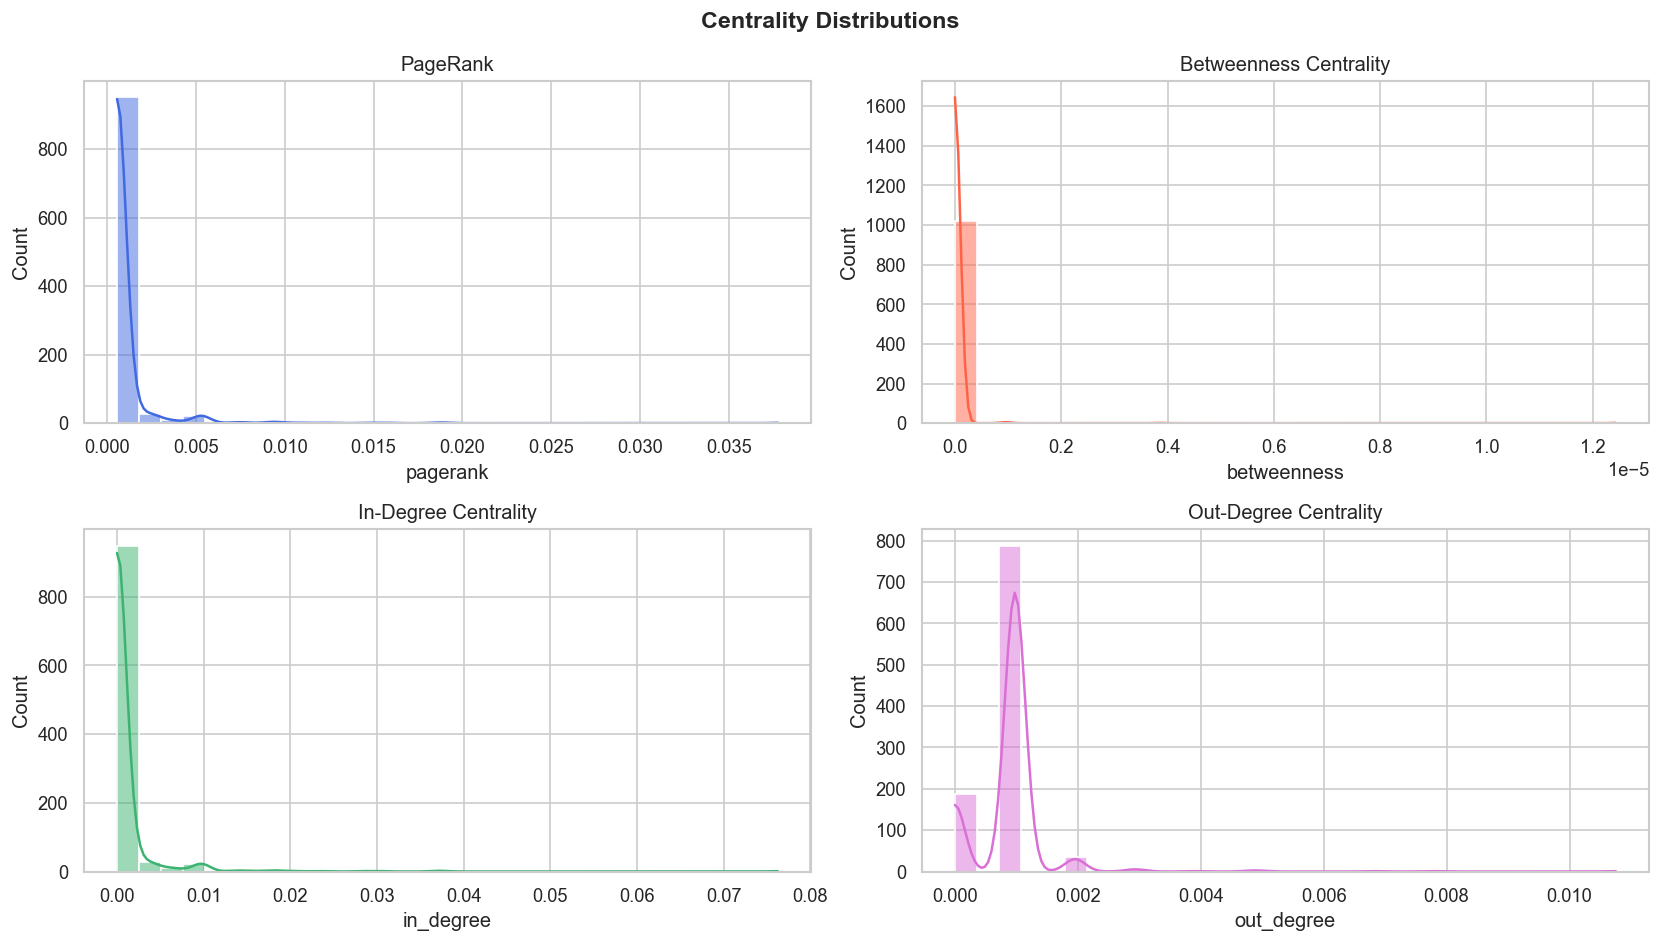

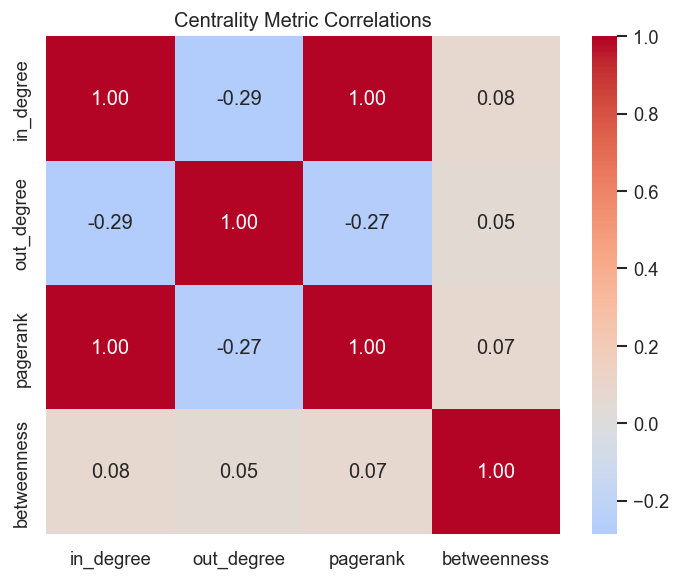

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

OUTPUT_DIR = Path('../output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def centrality_insights(df_c: pd.DataFrame):
    sep = '─' * 58
    print('\n' + sep + '\n💡  CENTRALITY INSIGHTS\n' + sep)

    print(f'🏆  Most Influential (PageRank)   : {df_c.nlargest(3,"pagerank")["username"].tolist()}')
    print(f'🚀  Most Active (Out-Degree)      : {df_c.nlargest(3,"out_degree")["username"].tolist()}')
    print(f'🔗  Most Connected (Total Degree) : {df_c.nlargest(3,"total_degree")["username"].tolist()}')
    print(f'🌉  Most Bridging (Betweenness)   : {df_c.nlargest(3,"betweenness")["username"].tolist()}')

    corr_cols = ['in_degree', 'out_degree', 'pagerank', 'betweenness']
    corr = df_c[corr_cols].corr()
    print('\n📊  Centrality Correlation Matrix:')
    display(corr.round(3))
    print(sep)

    # Distribution plots
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle('Centrality Distributions', fontsize=14, fontweight='bold')
    for ax, (c, title, color) in zip(axes.flatten(), [
        ('pagerank',    'PageRank',               'royalblue'),
        ('betweenness', 'Betweenness Centrality', 'tomato'),
        ('in_degree',   'In-Degree Centrality',   'mediumseagreen'),
        ('out_degree',  'Out-Degree Centrality',  'orchid'),
    ]):
        sns.histplot(df_c[c], bins=30, ax=ax, color=color, kde=True)
        ax.set_title(title)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/centrality_distributions.png', bbox_inches='tight')
    plt.show()

    # Heatmap
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
    ax.set_title('Centrality Metric Correlations')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/centrality_correlation.png', bbox_inches='tight')
    plt.show()


centrality_insights(df_centrality)

In [65]:
def normalize_series(s: pd.Series) -> pd.Series:
    min_val, max_val = s.min(), s.max()
    if max_val == min_val:
        return pd.Series(0.0, index=s.index)
    return (s - min_val) / (max_val - min_val)


def assign_tier(pct: float) -> tuple:
    if pct >= 99:   return 1, 'Mega Influencer'
    elif pct >= 95: return 2, 'Macro Influencer'
    elif pct >= 80: return 3, 'Mid Influencer'
    elif pct >= 50: return 4, 'Micro Influencer'
    else:           return 5, 'Regular User'


def compute_influence_scores(df_c: pd.DataFrame) -> pd.DataFrame:
    df_i = df_c[['username', 'in_degree', 'out_degree',
                  'total_degree', 'pagerank', 'betweenness']].copy()

    for c in ['pagerank', 'betweenness', 'in_degree', 'out_degree']:
        df_i[f'{c}_norm'] = normalize_series(df_i[c])

    df_i['influence_score'] = (
        df_i['pagerank_norm']    * 0.4 +
        df_i['betweenness_norm'] * 0.3 +
        df_i['in_degree_norm']   * 0.3
    )
    df_i['influence_percentile'] = df_i['influence_score'].rank(pct=True) * 100

    tiers = df_i['influence_percentile'].apply(assign_tier)
    df_i['tier']       = tiers.apply(lambda x: x[0])
    df_i['tier_label'] = tiers.apply(lambda x: x[1])

    df_i = df_i.drop(columns=[c for c in df_i.columns if c.endswith('_norm')])
    df_i = df_i.sort_values('influence_score', ascending=False).reset_index(drop=True)
    return df_i


df_influencer = compute_influence_scores(df_centrality)
display(df_influencer.head(20))

print('\n📊  Tier Distribution:')
print(df_influencer['tier_label'].value_counts().to_string())

,username,in_degree,out_degree,total_degree,pagerank,betweenness,influence_score,influence_percentile,tier,tier_label
0,sindonews,0.076246,0.000000,0.076246,0.037747,0.000000,0.700000,100.000000,1,Mega Influencer
1,genergibersih,0.009775,0.001955,0.011730,0.005156,0.000012,0.387779,99.902344,1,Mega Influencer
2,bitorexpost,0.037146,0.000000,0.037146,0.018996,0.000000,0.344395,99.804688,1,Mega Influencer
3,otoproject,0.037146,0.000000,0.037146,0.018589,0.000000,0.340017,99.707031,1,Mega Influencer
4,metrotv,0.030303,0.000000,0.030303,0.015636,0.000000,0.281322,99.609375,1,Mega Influencer
5,luarbioskop,0.028348,0.000000,0.028348,0.014531,0.000000,0.261740,99.511719,1,Mega Influencer
6,koranbaliexpress,0.023460,0.000000,0.023460,0.012235,0.000000,0.217797,99.414062,1,Mega Influencer
7,kompascom,0.020528,0.000000,0.020528,0.010777,0.000000,0.190573,99.316406,1,Mega Influencer
8,sukabumiupdatecom,0.018573,0.000000,0.018573,0.009805,0.000000,0.172423,99.218750,1,Mega Influencer
9,investordailyid,0.018573,0.000000,0.018573,0.009328,0.000000,0.167295,99.121094,1,Mega Influencer



📊  Tier Distribution:
tier_label
Regular User        828
Mid Influencer      144
Macro Influencer     41
Mega Influencer      11


In [66]:
# ── Config kolom ─────────────────────────────────────────────────────────────
COL = {
    'username'          : 'username',
    'total_interaction' : 'total_interaction'
}

# ── Business Questions ────────────────────────────────────────────────────────
def answer_business_questions(df_inf: pd.DataFrame,
                               df_raw: pd.DataFrame, col: dict) -> dict:
    sep = '═' * 62
    print('\n' + sep + '\n📋  BUSINESS QUESTION ANSWERS\n' + sep)

    uname = col['username']
    int_c = col['total_interaction']

    # Aggregate interaction per user dari raw data
    user_interact = {}
    if uname in df_raw.columns and int_c in df_raw.columns:
        user_interact = df_raw.groupby(uname)[int_c].sum().to_dict()

    q1 = df_inf[['username', 'influence_score', 'pagerank', 'tier_label']].head(10)
    print('\n🎯 Q1. Top Main Influencers (Influence Score + PageRank):')
    display(q1)

    q2 = df_inf.nlargest(10, 'betweenness')[['username', 'betweenness', 'tier_label']]
    print('\n🌉 Q2. Top Community Brokers (Betweenness Centrality):')
    display(q2)

    q3 = df_inf.nlargest(10, 'out_degree')[['username', 'out_degree', 'tier_label']].copy()
    q3['total_interaction'] = q3['username'].map(user_interact).fillna(0).astype(int)
    print('\n🚀 Q3. Most Active Mentioners (Out-Degree + Total Interaction):')
    display(q3)

    q4 = df_inf.nlargest(10, 'in_degree')[['username', 'in_degree', 'tier_label']]
    print('\n📣 Q4. Most Mentioned Accounts (In-Degree):')
    display(q4)

    narrative = f"""
{'═'*62}
📝  AUTOMATED BUSINESS NARRATIVE
{'═'*62}

🔹 Main Influencer: \"{q1.iloc[0]['username']}\" has the highest combined
   influence score and PageRank — likely a key opinion leader.

🔹 Top Broker: \"{q2.iloc[0]['username']}\" bridges separate community clusters.
   Engaging this account can maximise cross-community reach.

🔹 Most Active Mentioner: \"{q3.iloc[0]['username']}\" generates the most outbound
   mentions — a highly engaged or seeding account.

🔹 Most Mentioned: \"{q4.iloc[0]['username']}\" is most frequently tagged by others,
   indicating high community visibility and topic relevance.
{'═'*62}
    """
    print(narrative)
    return {'q1': q1, 'q2': q2, 'q3': q3, 'q4': q4}


biz_qa = answer_business_questions(df_influencer, df_raw, COL)


══════════════════════════════════════════════════════════════
📋  BUSINESS QUESTION ANSWERS
══════════════════════════════════════════════════════════════

🎯 Q1. Top Main Influencers (Influence Score + PageRank):


,username,influence_score,pagerank,tier_label
0,sindonews,0.700000,0.037747,Mega Influencer
1,genergibersih,0.387779,0.005156,Mega Influencer
2,bitorexpost,0.344395,0.018996,Mega Influencer
3,otoproject,0.340017,0.018589,Mega Influencer
4,metrotv,0.281322,0.015636,Mega Influencer
5,luarbioskop,0.261740,0.014531,Mega Influencer
6,koranbaliexpress,0.217797,0.012235,Mega Influencer
7,kompascom,0.190573,0.010777,Mega Influencer
8,sukabumiupdatecom,0.172423,0.009805,Mega Influencer
9,investordailyid,0.167295,0.009328,Mega Influencer



🌉 Q2. Top Community Brokers (Betweenness Centrality):


,username,betweenness,tier_label
1,genergibersih,1.243417e-05,Mega Influencer
13,lifeatgenb,3.825899e-06,Macro Influencer
51,katadatagreen,9.564747e-07,Macro Influencer
67,giz_idasean,9.564747e-07,Mid Influencer
68,joeliardisunendar,9.564747e-07,Mid Influencer
0,sindonews,0.000000e+00,Mega Influencer
2,bitorexpost,0.000000e+00,Mega Influencer
3,otoproject,0.000000e+00,Mega Influencer
4,metrotv,0.000000e+00,Mega Influencer
5,luarbioskop,0.000000e+00,Mega Influencer



🚀 Q3. Most Active Mentioners (Out-Degree + Total Interaction):


,username,out_degree,tier_label,total_interaction
571,merchandise_original_persib,0.010753,Regular User,0
942,aulia.rahmawati84,0.007820,Regular User,0
698,ratna_aden,0.006843,Regular User,0
385,friedo.hekya,0.004888,Regular User,3
565,maullyaariifiin,0.004888,Regular User,0
843,tututata151,0.004888,Regular User,2
535,validnews,0.003910,Regular User,0
281,cfdhack,0.002933,Regular User,0
758,aan101425,0.002933,Regular User,4
763,salsabillaurel,0.002933,Regular User,2



📣 Q4. Most Mentioned Accounts (In-Degree):


,username,in_degree,tier_label
0,sindonews,0.076246,Mega Influencer
2,bitorexpost,0.037146,Mega Influencer
3,otoproject,0.037146,Mega Influencer
4,metrotv,0.030303,Mega Influencer
5,luarbioskop,0.028348,Mega Influencer
6,koranbaliexpress,0.023460,Mega Influencer
7,kompascom,0.020528,Mega Influencer
8,sukabumiupdatecom,0.018573,Mega Influencer
9,investordailyid,0.018573,Mega Influencer
10,moltensalt.insight,0.017595,Mega Influencer



══════════════════════════════════════════════════════════════
📝  AUTOMATED BUSINESS NARRATIVE
══════════════════════════════════════════════════════════════

🔹 Main Influencer: "sindonews" has the highest combined
   influence score and PageRank — likely a key opinion leader.

🔹 Top Broker: "genergibersih" bridges separate community clusters.
   Engaging this account can maximise cross-community reach.

🔹 Most Active Mentioner: "merchandise_original_persib" generates the most outbound
   mentions — a highly engaged or seeding account.

🔹 Most Mentioned: "sindonews" is most frequently tagged by others,
   indicating high community visibility and topic relevance.
══════════════════════════════════════════════════════════════
    


In [67]:
import community as community_louvain  # pip install python-louvain

# Tentukan graph mana yang dipakai (combined/comment/mention)
G = graphs['combined']

# ── Louvain community detection ────────────────────────────────────────────
print('Running Louvain community detection...')

G_comm = G.copy()
G_comm.remove_edges_from(nx.selfloop_edges(G_comm))

MIN_EDGE_COUNT = 1

if MIN_EDGE_COUNT > 1:
    edges_to_keep = [
        (u, v, d)
        for u, v, d in G_comm.edges(data=True)
        if d.get('edge_count', 0) >= MIN_EDGE_COUNT
    ]
    G_filtered = nx.DiGraph()
    G_filtered.add_edges_from(edges_to_keep)
else:
    G_filtered = G_comm

isolates = list(nx.isolates(G_filtered))
G_filtered.remove_nodes_from(isolates)

G_undirected = G_filtered.to_undirected()

LOUVAIN_RANDOM_STATE = 42
LOUVAIN_RESOLUTION   = 0.3

if G_undirected.number_of_nodes() > 0:
    partition = community_louvain.best_partition(
        G_undirected,
        weight='weight',
        resolution=LOUVAIN_RESOLUTION,
        random_state=LOUVAIN_RANDOM_STATE
    )

    n_communities = len(set(partition.values()))

    try:
        modularity = community_louvain.modularity(
            partition, G_undirected, weight='weight'
        )
    except:
        modularity = None

    df_influencer['community_id'] = (
        df_influencer['username']
        .map(partition)
        .fillna(-1)
        .astype(int)
    )

    print(f"✅ Communities detected : {n_communities}")
    if modularity is not None:
        print(f"✅ Modularity score     : {modularity:.4f}")
    print(f"✅ Nodes used           : {G_undirected.number_of_nodes():,}")
    print(f"✅ Edges used           : {G_undirected.number_of_edges():,}")

    community_sizes = (
        df_influencer[df_influencer['community_id'] != -1]
        ['community_id']
        .value_counts()
        .sort_values(ascending=False)
    )

    print(f"\nTop 10 largest communities:")
    for i, (comm_id, size) in enumerate(community_sizes.head(10).items(), 1):
        print(f"  Community {comm_id}: {size:,} users")

else:
    print("⚠️ Graph is empty, skipping community detection")
    df_influencer['community_id'] = -1

Running Louvain community detection...
✅ Communities detected : 140
✅ Modularity score     : 0.9575
✅ Nodes used           : 1,024
✅ Edges used           : 920

Top 10 largest communities:
  Community 1: 76 users
  Community 95: 40 users
  Community 58: 39 users
  Community 19: 34 users
  Community 27: 32 users
  Community 44: 25 users
  Community 42: 22 users
  Community 16: 20 users
  Community 133: 19 users
  Community 29: 19 users


In [68]:
community_1_users = [node for node, cid in partition.items() if cid == 1]
print(f"Total user di community 1: {len(community_1_users)}")
print(community_1_users)

Total user di community 1: 76
['0h_gituh', 'sindonews', '4l3x42022', '76henikusumawati', 'aadhigunawans', 'achmad_mujaeni', 'adamramadhan767', 'aguspriyadiw', 'amiensedunia', 'andre2gd_', 'aswan2184', 'ayub7505', 'bananafirza4', 'bem_su1', 'brohar85', 'bslaksono', 'dion_siagian', 'dngcahyok', 'evander_manroe77', 'ezazafin', 'fitrianto971', 'gputra_andreass', 'grendygrey', 'haris449077', 'harya_pharis', 'hendriusman52', 'ichlasmohamad', 'ikayaji2407', 'ikhwan.averoes', 'indra_rachman19', 'itongeka', 'juangjoko', 'kartika1654', 'kurnianto_susetiyo', 'law_roes', 'lenibit.ch', 'marcoovp14', 'marhendraputra', 'mglenak', 'mhalim_real', 'muhammad2389arif', 'nabilxcy50', 'nation_027_', 'nitamia38', 'noorhasanah7757', 'nugraha.1st', 'om_nyoss', 'parap129', 'passeljemmy', 'penguasa.kegelapan666', 'prittapaw', 'renoor281971', 'resepnffam', 'rezapahlepie1', 'richard_ucayz', 'riisestia', 'rudi_wassalam', 'rwt_ramadhan', 'selamatabdurrahman99', 'sirdonda', 'suny1752', 'swarnorudi', 'syane.elis', 'ti

In [69]:
print(f"Graph yang dipakai untuk Louvain : {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Combined graph                   : {graphs['combined'].number_of_nodes()} nodes, {graphs['combined'].number_of_edges()} edges")
print(f"Sama? {G.number_of_nodes() == graphs['combined'].number_of_nodes()}")

Graph yang dipakai untuk Louvain : 1024 nodes, 921 edges
Combined graph                   : 1024 nodes, 921 edges
Sama? True


In [70]:
from scipy import stats

def compute_centrality(G, use_weighted_degree=False):
    print('⏳  Computing centrality metrics...')

    if use_weighted_degree:
        in_deg  = dict(G.in_degree(weight='weight'))
        out_deg = dict(G.out_degree(weight='weight'))
    else:
        in_deg  = nx.in_degree_centrality(G)
        out_deg = nx.out_degree_centrality(G)

    pr  = nx.pagerank(G, alpha=0.85, weight='weight')
    btw = nx.betweenness_centrality(G, normalized=True, weight='weight')

    nodes = list(G.nodes())
    df_c  = pd.DataFrame({
        'username'   : nodes,
        'in_degree'  : [in_deg.get(n, 0)  for n in nodes],
        'out_degree' : [out_deg.get(n, 0) for n in nodes],
        'pagerank'   : [pr.get(n, 0)      for n in nodes],
        'betweenness': [btw.get(n, 0)     for n in nodes],
    })

    df_c['total_degree'] = df_c['in_degree'] + df_c['out_degree']

    metric_cols = ['in_degree', 'out_degree', 'total_degree', 'pagerank', 'betweenness']
    for c in metric_cols:
        vals = df_c[c].fillna(0)
        df_c[f'{c}_zscore'] = 0.0 if vals.std() == 0 else stats.zscore(vals)
        df_c[f'{c}_pct']    = vals.rank(pct=True) * 100

    df_c = df_c.sort_values('pagerank', ascending=False).reset_index(drop=True)
    print('✅  Done.')
    return df_c

df_centrality_comment  = compute_centrality(graphs['comment'],  use_weighted_degree=False)
df_centrality_mention  = compute_centrality(graphs['mention'],  use_weighted_degree=True)
df_centrality_combined = compute_centrality(graphs['combined'], use_weighted_degree=False)

def normalize_series(s):
    min_val, max_val = s.min(), s.max()
    if max_val == min_val:
        return pd.Series(0.0, index=s.index)
    return (s - min_val) / (max_val - min_val)

def assign_tier(pct):
    if pct >= 99:   return 1, 'Mega Influencer'
    elif pct >= 95: return 2, 'Macro Influencer'
    elif pct >= 80: return 3, 'Mid Influencer'
    elif pct >= 50: return 4, 'Micro Influencer'
    else:           return 5, 'Regular User'

def compute_influence_scores(df_c):
    df_i = df_c[['username', 'in_degree', 'out_degree', 'total_degree', 'pagerank', 'betweenness']].copy()
    for c in ['pagerank', 'betweenness', 'in_degree', 'out_degree']:
        df_i[f'{c}_norm'] = normalize_series(df_i[c])
    df_i['influence_score'] = (
        df_i['pagerank_norm']    * 0.4 +
        df_i['betweenness_norm'] * 0.3 +
        df_i['in_degree_norm']   * 0.3
    )
    df_i['influence_percentile'] = df_i['influence_score'].rank(pct=True) * 100
    tiers = df_i['influence_percentile'].apply(assign_tier)
    df_i['tier']       = tiers.apply(lambda x: x[0])
    df_i['tier_label'] = tiers.apply(lambda x: x[1])
    df_i = df_i.drop(columns=[c for c in df_i.columns if c.endswith('_norm')])
    df_i = df_i.sort_values('influence_score', ascending=False).reset_index(drop=True)
    return df_i

df_influencer_comment  = compute_influence_scores(df_centrality_comment)
df_influencer_mention  = compute_influence_scores(df_centrality_mention)
df_influencer_combined = compute_influence_scores(df_centrality_combined)
df_influencer          = df_influencer_combined

⏳  Computing centrality metrics...
✅  Done.
⏳  Computing centrality metrics...
✅  Done.
⏳  Computing centrality metrics...
✅  Done.


In [71]:
from collections import Counter

COL = {
    'username'          : 'username',
    'total_interaction' : 'total_interaction',
    'total_like'        : 'total_like',
    'keyword'           : 'keyword',
    'sentiment_label'   : 'sentiment_label',
    'post_id'           : 'post_id',
    'is_comment'        : 'is_comment'
}

def build_community_df(G, partition, df_inf, df_raw, col) -> pd.DataFrame:
    communities = {}
    for node, cid in partition.items():
        communities.setdefault(cid, []).append(node)

    uname_c = col['username']
    kw_col  = col['keyword']
    senti_c = col['sentiment_label']
    isc_c   = col['is_comment']

    def top_keywords(users, n=5):
        if kw_col not in df_raw.columns: return [], 'N/A'
        kws_series = df_raw[df_raw[uname_c].isin(users)][kw_col].dropna().astype(str).str.strip()
        if kws_series.empty: return [], 'N/A'
        freq = Counter(kws_series)
        top  = [kw for kw, _ in freq.most_common(n)]
        return top, top[0] if top else 'N/A'

    def dominant_sentiment(users):
        if senti_c not in df_raw.columns: return 'N/A'
        s = df_raw[df_raw[uname_c].isin(users)][senti_c].dropna()
        return s.mode().iloc[0] if not s.empty else 'N/A'

    rows = []
    for cid, members in communities.items():
        sub = df_inf[df_inf['username'].isin(members)]

        # ── Top influencer dengan tie handling ───────────────────────────
        if sub.empty:
            top_inf_val = 'N/A'
        else:
            max_score          = sub['influence_score'].max()
            top_inf_candidates = sub[sub['influence_score'] == max_score]
            if len(top_inf_candidates) > 1:
                top_inf_val = 'tied'  # tied — skor sama semua
            else:
                top_inf_val = top_inf_candidates['username'].values[0]

        # ── Top broker ───────────────────────────────────────────────────
        if sub.empty:
            top_brk_val = 'N/A'
        else:
            max_btw          = sub['betweenness'].max()
            top_brk_candidates = sub[sub['betweenness'] == max_btw]
            if len(top_brk_candidates) > 1:
                top_brk_val = 'tied'
            else:
                top_brk_val = top_brk_candidates['username'].values[0]

        subG      = G.subgraph(members)
        int_edges = subG.number_of_edges()
        tot_edges = sum(1 for u, v in G.edges() if u in members or v in members)
        ext_edges = tot_edges - int_edges

        kw_list, dom_kw = top_keywords(members)

        tier1_count = int(sub[sub['tier'] == 1].shape[0])
        tier2_count = int(sub[sub['tier'] == 2].shape[0])

        comm_nodes_raw      = df_raw[df_raw[uname_c].isin(members)]
        total_comments_recv = int(
            comm_nodes_raw[comm_nodes_raw[isc_c] == True].shape[0]
            if isc_c in comm_nodes_raw.columns else 0
        )

        rows.append({
            'community_id'        : cid,
            'size'                : len(members),
            'top_influencer'      : top_inf_val,
            'top_broker'          : top_brk_val,
            'dominant_keyword'    : dom_kw,
            'keyword_diversity'   : len(set(kw_list)),
            'top_keywords'        : json.dumps(kw_list),
            'dominant_sentiment'  : dominant_sentiment(members),
            'interaction_density' : round(nx.density(subG), 4),
            'internal_edges'      : int_edges,
            'external_edges'      : ext_edges,
            'internal_edge_ratio' : round(int_edges / tot_edges, 3) if tot_edges else 0,
            'tier1_count'         : tier1_count,
            'tier2_count'         : tier2_count,
            'total_comments_recv' : total_comments_recv,
        })

    return pd.DataFrame(rows).sort_values('size', ascending=False).reset_index(drop=True)


df_communities = build_community_df(G, partition, df_influencer_combined, df_raw, COL)
display(df_communities)

,community_id,size,top_influencer,top_broker,dominant_keyword,keyword_diversity,top_keywords,dominant_sentiment,interaction_density,internal_edges,external_edges,internal_edge_ratio,tier1_count,tier2_count,total_comments_recv
0,1,76,sindonews,tied,ProduksiMinyak,3,"[""ProduksiMinyak"", ""KrisisEnergi"", ""KonsumsiBBM""]",Negative,0.0132,75,3,0.962,1,0,76
1,95,40,bitorexpost,tied,ProduksiMinyak,3,"[""ProduksiMinyak"", ""KrisisEnergi"", ""SubsidiBBM""]",Negative,0.0250,39,0,1.000,1,0,38
2,58,39,otoproject,tied,ProduksiMinyak,2,"[""ProduksiMinyak"", ""KenaikanhargaBBM""]",Neutral,0.0256,38,2,0.950,1,0,42
3,19,34,luarbioskop,tied,ProduksiMinyak,3,"[""ProduksiMinyak"", ""KrisisEnergi"", ""MinyakIndo...",Positive,0.0294,33,0,1.000,1,0,29
4,27,32,metrotv,tied,ProduksiMinyak,3,"[""ProduksiMinyak"", ""SubsidiBBM"", ""KrisisEnergi""]",Negative,0.0312,31,0,1.000,1,0,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,113,2,sorotan,tied,SubsidiBBM,1,"[""SubsidiBBM""]",Positive,0.5000,1,0,1.000,0,0,0
136,131,2,icmofficial,tied,KrisisEnergi,1,"[""KrisisEnergi""]",Neutral,0.5000,1,0,1.000,0,0,0
137,125,2,matanajwa,tied,KonsumsiBBM,1,"[""KonsumsiBBM""]",Positive,0.5000,1,0,1.000,0,0,0
138,135,2,ratihandriyani,tied,KrisisEnergi,1,"[""KrisisEnergi""]",Positive,0.5000,1,0,1.000,0,0,0



──────────────────────────────────────────────────────────
😊  SENTIMENT-INFLUENCE CORRELATION
──────────────────────────────────────────────────────────

📊  Average Metrics by Dominant Sentiment:


,influence_score,pagerank,betweenness
dominant_sentiment,,,
Negative,0.007004,0.000941,0.0
Neutral,0.008673,0.000972,0.0
Positive,0.009296,0.001035,0.0


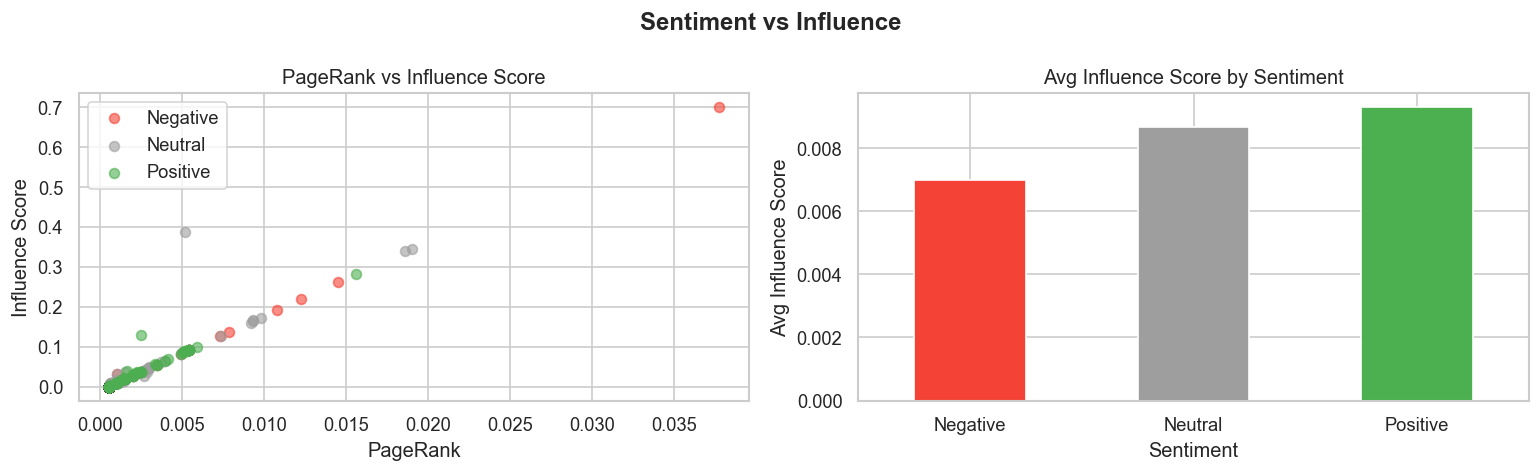


💡  Dominant "Positive" sentiment → highest avg influence.
✅  Positive accounts lead — healthy community signal.
──────────────────────────────────────────────────────────


In [72]:
def sentiment_influence_correlation(df_inf, df_raw, col):
    sep = '─' * 58
    print('\n' + sep + '\n😊  SENTIMENT-INFLUENCE CORRELATION\n' + sep)

    senti_c = col['sentiment_label']
    uname_c = col['username']
    if senti_c not in df_raw.columns:
        print('⚠️  sentiment_label column not found.')
        return pd.DataFrame()

    dom_senti = (
        df_raw.dropna(subset=[uname_c, senti_c])
        .groupby(uname_c)[senti_c]
        .apply(lambda x: x.mode().iloc[0])
        .reset_index()
        .rename(columns={senti_c: 'dominant_sentiment'})
    )

    df_si = df_inf.merge(dom_senti, on='username', how='left')
    df_si['dominant_sentiment'] = df_si['dominant_sentiment'].fillna('Neutral')

    avg_by_s = df_si.groupby('dominant_sentiment')[
        ['influence_score', 'pagerank', 'betweenness']
    ].mean().round(6)

    print('\n📊  Average Metrics by Dominant Sentiment:')
    display(avg_by_s)

    c_map = {
        'Positive': '#4CAF50', 'Negative': '#F44336', 'Neutral': '#9E9E9E',
        'positive': '#4CAF50', 'negative': '#F44336', 'neutral': '#9E9E9E'
    }

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle('Sentiment vs Influence', fontweight='bold')

    ax = axes[0]
    for s, grp in df_si.groupby('dominant_sentiment'):
        ax.scatter(grp['pagerank'], grp['influence_score'],
                   label=s, alpha=0.6, color=c_map.get(s, 'blue'), s=35)
    ax.set_xlabel('PageRank')
    ax.set_ylabel('Influence Score')
    ax.set_title('PageRank vs Influence Score')
    ax.legend()

    ax = axes[1]
    avg_by_s['influence_score'].plot(
        kind='bar', ax=ax,
        color=[c_map.get(s, 'gray') for s in avg_by_s.index]
    )
    ax.set_title('Avg Influence Score by Sentiment')
    ax.set_xlabel('Sentiment')
    ax.set_ylabel('Avg Influence Score')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/sentiment_influence.png', bbox_inches='tight')
    plt.show()

    best_s = avg_by_s['influence_score'].idxmax()
    print(f'\n💡  Dominant "{best_s}" sentiment → highest avg influence.')
    if 'Negative' in avg_by_s.index and 'Positive' in avg_by_s.index:
        if avg_by_s.loc['Negative', 'influence_score'] > avg_by_s.loc['Positive', 'influence_score']:
            print('⚠️  Negative accounts appear more influential — watch for viral negativity.')
        else:
            print('✅  Positive accounts lead — healthy community signal.')

    print(sep)
    return df_si


df_senti_corr = sentiment_influence_correlation(df_influencer, df_raw, COL)

In [73]:
import json

# ── Update COL config ────────────────────────────────────────────────────────
COL = {
    'username'          : 'username',
    'total_interaction' : 'total_interaction',
    'total_like'        : 'total_like',
    'keyword'           : 'keyword',
    'sentiment_label'   : 'sentiment_label',
    'post_id'           : 'post_id',
    'is_comment'        : 'is_comment'
}

# ── df_whitespace (kosong kalau belum ada) ───────────────────────────────────
df_whitespace = pd.DataFrame()

In [74]:
print(df_raw.columns.tolist())

['date', 'keyword', 'url', 'content', 'username', 'total_like', 'total_interaction', 'content_processed', 'sentiment_label', 'sentiment_score', 'post_id', 'comment_id', 'is_comment', 'year_month', 'day_of_week', 'hour', 'mentions', 'hashtags', 'n_mentions', 'n_hashtags']


In [75]:
import json

# ── COL config ───────────────────────────────────────────────────────────────
COL = {
    'username'          : 'username',
    'total_interaction' : 'total_interaction',
    'total_like'        : 'total_like',
    'keyword'           : 'keyword',
    'sentiment_label'   : 'sentiment_label',
    'post_id'           : 'post_id',
    'is_comment'        : 'is_comment'
}

# ── df_whitespace (kosong kalau belum ada) ───────────────────────────────────
df_whitespace = pd.DataFrame()

In [76]:
print(f"n_communities : {n_communities}")
print(f"modularity    : {modularity}")

n_communities : 140
modularity    : 0.9575153480257533


In [77]:
modularity_score = modularity
print(f"Modularity score: {modularity_score}")

Modularity score: 0.9575153480257533


In [78]:
# Hitung influence score per graph
df_influencer_comment  = compute_influence_scores(df_centrality_comment)
df_influencer_mention  = compute_influence_scores(df_centrality_mention)
df_influencer_combined = compute_influence_scores(df_centrality_combined)

# Primary tetap combined
df_influencer = df_influencer_combined

# Cek perbandingan untuk satu user
user = 'sindonews'

for name, df_inf in [('comment', df_influencer_comment),
                      ('mention', df_influencer_mention),
                      ('combined', df_influencer_combined)]:
    row = df_inf[df_inf['username'] == user]
    if not row.empty:
        print(f"{name:10s} → influence_score: {row['influence_score'].values[0]:.6f} | tier: {row['tier_label'].values[0]}")
    else:
        print(f"{name:10s} → {user} tidak ada di graph ini")

comment    → influence_score: 0.700000 | tier: Mega Influencer
mention    → sindonews tidak ada di graph ini
combined   → influence_score: 0.700000 | tier: Mega Influencer


In [79]:
def export_graph_json(
    G, graph_name, df_inf, df_communities, partition,
    df_raw, col, modularity_score, df_whitespace=None, output_dir=OUTPUT_DIR
):
    output_path = f'{output_dir}/graph_data_{graph_name}.json'

    uname_c = col['username']
    int_c   = col['total_interaction']
    like_c  = col['total_like']
    senti_c = col['sentiment_label']
    post_c  = col['post_id']
    isc_c   = col['is_comment']
    kw_c    = col.get('keyword', 'keyword')

    graph_nodes      = set(G.nodes())
    raw_in_degree    = dict(G.in_degree())
    raw_out_degree   = dict(G.out_degree())
    raw_total_degree = {n: raw_in_degree.get(n, 0) + raw_out_degree.get(n, 0) for n in G.nodes()}

    user_stats = {}
    for u, grp in df_raw.groupby(uname_c):
        if u not in graph_nodes:
            continue
        post_cnt    = int((grp[isc_c] == False).sum()) if isc_c in grp.columns else 0
        comment_cnt = int((grp[isc_c] == True).sum())  if isc_c in grp.columns else len(grp)
        total_int   = float(grp[int_c].sum())           if int_c  in grp.columns else 0.0
        avg_int     = round(float(grp[int_c].mean()), 2) if int_c in grp.columns else 0.0
        total_like  = float(grp[like_c].sum())          if like_c in grp.columns else 0.0
        dom_senti   = 'Neutral'
        if senti_c in grp.columns:
            s = grp[senti_c].dropna()
            dom_senti = s.mode().iloc[0] if not s.empty else 'Neutral'
        dom_kw, kws = 'N/A', []
        if kw_c in grp.columns:
            kw_vals = grp[kw_c].dropna().astype(str).str.strip()
            if not kw_vals.empty:
                freq   = Counter(kw_vals)
                dom_kw = freq.most_common(1)[0][0]
                kws    = [kw for kw, _ in freq.most_common(5)]
        user_stats[u] = {
            'post_count'           : post_cnt,
            'total_comments_recv'  : comment_cnt,
            'total_interaction'    : total_int,
            'avg_interaction'      : avg_int,
            'total_post_like'      : total_like,
            'dominant_sentiment'   : dom_senti,
            'dominant_keyword_node': dom_kw,
            'active_keyword'       : kws,
        }

    comm_kw = df_communities.set_index('community_id')['dominant_keyword'].to_dict()
    inf_idx = df_inf.set_index('username').to_dict(orient='index')

    nodes_export = []
    for node in G.nodes():
        inf   = inf_idx.get(node, {})
        stats = user_stats.get(node, {})
        cid   = partition.get(node, -1)
        nodes_export.append({
            'id'                   : node,
            'username'             : node,
            'influence_score'      : round(float(inf.get('influence_score', 0) or 0), 6),
            'tier'                 : int(inf.get('tier', 5) or 5),
            'tier_label'           : str(inf.get('tier_label', 'Regular User')),
            'pagerank'             : round(float(inf.get('pagerank', 0) or 0), 8),
            'betweenness'          : round(float(inf.get('betweenness', 0) or 0), 8),
            'in_degree'            : raw_in_degree.get(node, 0),
            'out_degree'           : raw_out_degree.get(node, 0),
            'total_degree'         : raw_total_degree.get(node, 0),
            'post_count'           : stats.get('post_count', 0),
            'total_comments_recv'  : stats.get('total_comments_recv', 0),
            'total_interaction'    : stats.get('total_interaction', 0.0),
            'avg_interaction'      : stats.get('avg_interaction', 0.0),
            'total_post_like'      : stats.get('total_post_like', 0.0),
            'dominant_sentiment'   : stats.get('dominant_sentiment', 'Neutral'),
            'dominant_keyword'     : comm_kw.get(cid, 'N/A'),
            'dominant_keyword_node': stats.get('dominant_keyword_node', 'N/A'),
            'community_id'         : cid,
            'active_keywords'      : stats.get('active_keyword', []),
        })

    nodes_export.sort(key=lambda x: x['influence_score'], reverse=True)

    edges_export = []
    for u, v, data in G.edges(data=True):
        has_comment = data.get('has_comment', False)
        has_mention = data.get('has_mention', False)
        if has_comment and has_mention: edge_type = 'comment+mention'
        elif has_mention:               edge_type = 'mention'
        else:                           edge_type = 'comment'
        edges_export.append({
            'source'    : u,
            'target'    : v,
            'weight'    : round(float(data.get('weight', 1)), 4),
            'edge_count': int(data.get('edge_count', 1)),
            'edge_type' : edge_type,
        })

    edge_type_counts     = Counter(e['edge_type'] for e in edges_export)
    G_und                = G.to_undirected()
    components           = list(nx.connected_components(G_und))
    largest_cc           = max(components, key=len) if components else []
    lcc_ratio            = len(largest_cc) / G.number_of_nodes() if G.number_of_nodes() else 0
    graph_community_ids  = set(partition.get(n, -1) for n in graph_nodes)
    communities_export   = df_communities[df_communities['community_id'].isin(graph_community_ids)].to_dict('records')
    whitespace_export    = df_whitespace[df_whitespace['community_id'].isin(graph_community_ids)].to_dict('records') if df_whitespace is not None and not df_whitespace.empty else []

    metadata = {
        'graph_name'        : graph_name,
        'total_nodes'       : G.number_of_nodes(),
        'total_edges'       : G.number_of_edges(),
        'density'           : round(nx.density(G), 8),
        'modularity'        : round(float(modularity_score), 6),
        'n_communities'     : len(graph_community_ids - {-1}),
        'lcc_size'          : len(largest_cc),
        'lcc_ratio'         : round(lcc_ratio, 4),
        'edge_architecture' : 'comment-on-post (PRIMARY) + mention (LAYER 2)',
        'edge_type_counts'  : dict(edge_type_counts),
    }

    graph_data = {
        'metadata'   : metadata,
        'nodes'      : nodes_export,
        'edges'      : edges_export,
        'communities': communities_export,
        'whitespace' : whitespace_export,
    }

    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump(graph_data, f, ensure_ascii=False, indent=2, default=str)

    print(f'✅  {graph_name:<10} → {output_path}')
    print(f'    Nodes: {len(nodes_export):,} | Edges: {len(edges_export):,}')
    print(f'    Communities: {len(communities_export):,} | Edge types: {dict(edge_type_counts)}')
    return graph_data


# ── Run export ────────────────────────────────────────────────────────────────
modularity_score = modularity if modularity is not None else 0.0

print('💾  Exporting JSON files...')
print('─' * 55)

base_kwargs = dict(
    df_communities   = df_communities,
    partition        = partition,
    df_raw           = df_raw,
    col              = COL,
    modularity_score = modularity_score,
    df_whitespace    = df_whitespace,
    output_dir       = OUTPUT_DIR,
)

graph_data_combined1 = export_graph_json(G=graphs['combined'], graph_name='combined', df_inf=df_influencer_combined, **base_kwargs)
graph_data_comment1  = export_graph_json(G=graphs['comment'],  graph_name='comment',  df_inf=df_influencer_comment,  **base_kwargs)
graph_data_mention1  = export_graph_json(G=graphs['mention'],  graph_name='mention',  df_inf=df_influencer_mention,  **base_kwargs)

print('─' * 55)
print(f'\n📄  Sample node (combined):')
print(json.dumps(graph_data_combined1['nodes'][0], indent=2, ensure_ascii=False))
print(f'\n📄  Sample edge (combined):')
print(json.dumps(graph_data_combined1['edges'][0], indent=2, ensure_ascii=False))

💾  Exporting JSON files...
───────────────────────────────────────────────────────
✅  combined   → ..\output/graph_data_combined.json
    Nodes: 1,024 | Edges: 921
    Communities: 140 | Edge types: {'comment': 819, 'mention': 98, 'comment+mention': 4}
✅  comment    → ..\output/graph_data_comment.json
    Nodes: 931 | Edges: 823
    Communities: 123 | Edge types: {'comment': 823}
✅  mention    → ..\output/graph_data_mention.json
    Nodes: 139 | Edges: 102
    Communities: 46 | Edge types: {'comment': 102}
───────────────────────────────────────────────────────

📄  Sample node (combined):
{
  "id": "sindonews",
  "username": "sindonews",
  "influence_score": 0.7,
  "tier": 1,
  "tier_label": "Mega Influencer",
  "pagerank": 0.03774687,
  "betweenness": 0.0,
  "in_degree": 78,
  "out_degree": 0,
  "total_degree": 78,
  "post_count": 14,
  "total_comments_recv": 0,
  "total_interaction": 0.0,
  "avg_interaction": 0.0,
  "total_post_like": 4350.0,
  "dominant_sentiment": "Negative",
  "do

In [80]:
top_in = sorted(
    graphs['mention'].in_degree(),
    key=lambda x: x[1],
    reverse=True
)[:10]

top_out = sorted(
    graphs['mention'].out_degree(),
    key=lambda x: x[1],
    reverse=True
)[:10]

print("TOP IN")
print(top_in)

print("TOP OUT")
print(top_out)

TOP IN
[('prabowo', 7), ('riyan.nurrahman', 6), ('bahlillahadalia', 3), ('alif.m.ismail', 3), ('yuliawati.792', 2), ('kesdm', 2), ('pertamina', 2), ('dpr_ri', 2), ('kompascom', 2), ('satya.bumi', 2)]
TOP OUT
[('merchandise_original_persib', 10), ('aulia.rahmawati84', 8), ('ratna_aden', 6), ('friedo.hekya', 4), ('maullyaariifiin', 4), ('validnews', 4), ('350id', 3), ('cerita.rame', 3), ('ditlitka.ppidunia', 2), ('genergibersih', 2)]


In [81]:
# Gabungkan ketiga df_influencer
df_cmp = df_influencer_combined[['username', 'influence_score']].rename(columns={'influence_score': 'combined'})
df_cmp = df_cmp.merge(
    df_influencer_comment[['username', 'influence_score']].rename(columns={'influence_score': 'comment'}),
    on='username', how='outer'
)
df_cmp = df_cmp.merge(
    df_influencer_mention[['username', 'influence_score']].rename(columns={'influence_score': 'mention'}),
    on='username', how='outer'
)

df_cmp = df_cmp.fillna(0).round(6)

# Filter yang nilainya beda di ketiga network
df_diff = df_cmp[
    (df_cmp['combined'] != df_cmp['comment']) |
    (df_cmp['combined'] != df_cmp['mention']) |
    (df_cmp['comment']  != df_cmp['mention'])
].sort_values('combined', ascending=False)

print(f"Total username dengan nilai beda : {len(df_diff)}")
print(df_diff.to_string())

Total username dengan nilai beda : 196
                     username  combined   comment   mention
852                 sindonews  0.700000  0.700000  0.000000
357             genergibersih  0.387779  0.090749  0.000000
192               bitorexpost  0.344395  0.344846  0.000000
678                otoproject  0.340017  0.340027  0.077500
589                   metrotv  0.281322  0.272247  0.117500
545               luarbioskop  0.261740  0.263172  0.000000
523          koranbaliexpress  0.217797  0.217797  0.000000
521                 kompascom  0.190573  0.181498  0.235000
877         sukabumiupdatecom  0.172423  0.172423  0.000000
448           investordailyid  0.167295  0.167295  0.117500
609        moltensalt.insight  0.163348  0.163348  0.000000
496              katadatacoid  0.158272  0.145198  0.117500
337         feedcollective.co  0.136123  0.136123  0.000000
539                lifeatgenb  0.128169  0.036300  0.000000
193          bloombergtechnoz  0.127049  0.127049  0.000000
9

In [82]:
# Cek nilai asli di JSON
node = next((n for n in graph_data_combined1['nodes'] if n['username'] == 'genergibersih'), None)
print(f"betweenness di JSON: {node['betweenness']}")

betweenness di JSON: 1.243e-05


In [83]:
# Cek tier1 dan tier2 count di top 10 communities
top10 = df_communities.head(10)

print("Top 10 Communities — Tier Count:")
print(f"{'Community':>12} {'Size':>6} {'T1':>4} {'T2':>4}")
print('-' * 32)
for _, row in top10.iterrows():
    print(f"#{row['community_id']:>10} {row['size']:>6} {row['tier1_count']:>4} {row['tier2_count']:>4}")

Top 10 Communities — Tier Count:
   Community   Size   T1   T2
--------------------------------
#         1     76    1    0
#        95     40    1    0
#        58     39    1    0
#        19     34    1    0
#        27     32    1    0
#        44     25    1    0
#        42     22    1    0
#        16     20    1    0
#        29     19    1    0
#       133     19    1    0


In [84]:
print(df_influencer_combined['tier'].value_counts().sort_index())

tier
1     11
2     41
3    144
5    828
Name: count, dtype: int64


In [85]:
print(df_influencer['tier'].value_counts().sort_index())

tier
1     11
2     41
3    144
5    828
Name: count, dtype: int64


In [86]:
# Cek apakah tier 2 ada di members community terbesar
cid = df_communities.iloc[0]['community_id']
members = [node for node, c in partition.items() if c == cid]

sub = df_influencer_combined[df_influencer_combined['username'].isin(members)]
print(sub['tier'].value_counts())
print(f"\nTier 2 count: {sub[sub['tier'] == 2].shape[0]}")

tier
5    75
1     1
Name: count, dtype: int64

Tier 2 count: 0


In [87]:
print(df_communities[df_communities['tier2_count'] > 0][['community_id', 'size', 'tier1_count', 'tier2_count']].to_string())

     community_id  size  tier1_count  tier2_count
10             17    18            0            1
11             25    16            0            1
12             15    16            0            1
13             68    15            0            1
14             74    14            0            1
16             11    13            0            1
17              8    13            1            1
18             64    12            0            1
19             47    12            0            1
20             77    12            0            1
21             50    11            0            1
22             63    11            0            1
23              3    11            0            1
24             45    11            0            1
25             86    11            0            1
26             51    11            0            1
27             60    11            0            1
28             38    11            0            1
29             80    11            0            1


In [88]:
# Cek community 10 di mention graph
members_10 = [node for node, cid in partition.items() if cid == 10]

# Bandingkan influence score dari ketiga df_influencer
for name, df_inf in [('comment',  df_influencer_comment),
                     ('mention',  df_influencer_mention),
                     ('combined', df_influencer_combined)]:
    sub = df_inf[df_inf['username'].isin(members_10)][['username', 'influence_score', 'pagerank', 'tier']]
    print(f"\n{name}:")
    print(sub.sort_values('influence_score', ascending=False).to_string())


comment:
         username  influence_score  pagerank  tier
80   mkiofficial_          0.01815  0.001669     3
607   mo.moko7390          0.00000  0.000618     5
694  rachmatdosen          0.00000  0.000618     5

mention:
Empty DataFrame
Columns: [username, influence_score, pagerank, tier]
Index: []

combined:
         username  influence_score  pagerank  tier
78   mkiofficial_          0.01815  0.001544     3
582   mo.moko7390          0.00000  0.000572     5
687  rachmatdosen          0.00000  0.000572     5
